# Comparación de kernels SVM (lineal, polinómico y RBF)
Notebook de práctica 

**Dataset:** `dataset_svm_3features.csv` (x1, x2, x3, y)


## 1. Importaciones y configuración
Importamos librerías que nos harán falta

In [2]:
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.tree import export_graphviz
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_squared_error, mean_absolute_error, r2_score

## 2. Carga del dataset

Asegúrate de que el Dataset es correcto y está en la ruta adecuada

In [3]:
df_games = pd.read_csv("dataset_svm_3.csv")
df_games.head()

,x1,x2,x3,y
0,1.956471,0.522024,3.729120,1
1,1.028349,-0.815309,0.344379,1
2,0.772477,0.487892,0.585373,0
3,-0.546762,0.550913,0.528503,0
4,0.931783,0.307020,0.692005,0


## 3. Exploración del Dataset

Estudia las características más importantes del Dataset: Estructura, tipos, entre otras

INFORMACIÓN DEL DATASET

Forma del dataset: (1200, 4)

Tipos de datos:
x1    float64
x2    float64
x3    float64
y       int64
dtype: object

Estadísticas descriptivas:
                x1           x2           x3            y
count  1200.000000  1200.000000  1200.000000  1200.000000
mean      0.495628     0.245578     0.724498     0.500000
std       0.908439     0.546897     1.496208     0.500208
min      -1.517920    -1.044313    -2.523007     0.000000
25%      -0.144652    -0.189703    -0.228058     0.000000
50%       0.500767     0.241160     0.357092     0.500000
75%       1.149854     0.684919     1.332938     1.000000
max       2.503825     1.624435     6.471865     1.000000

Valores nulos:
x1    0
x2    0
x3    0
y     0
dtype: int64

CONTEO DE CEROS EN CADA VARIABLE
  x1  :    0 ceros ( 0.00%)
  x2  :    0 ceros ( 0.00%)
  x3  :    0 ceros ( 0.00%)
  y   :  600 ceros (50.00%)

INFORMACIÓN SOBRE LAS CLASES

Número total de clases: 2
Clases encontradas: [np.int64(0), np.int64(1)

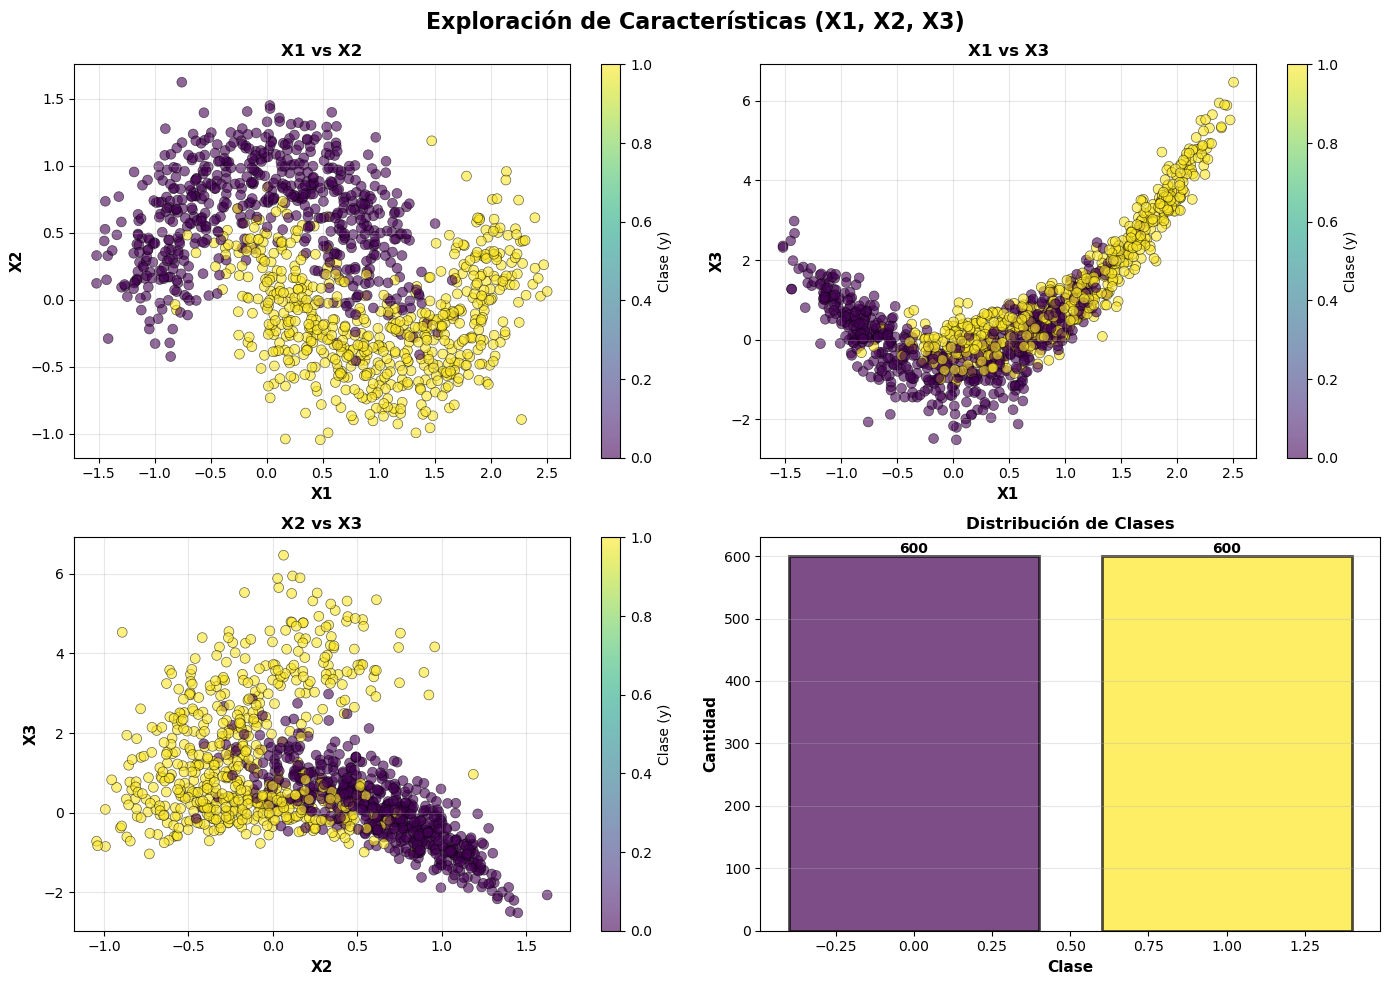

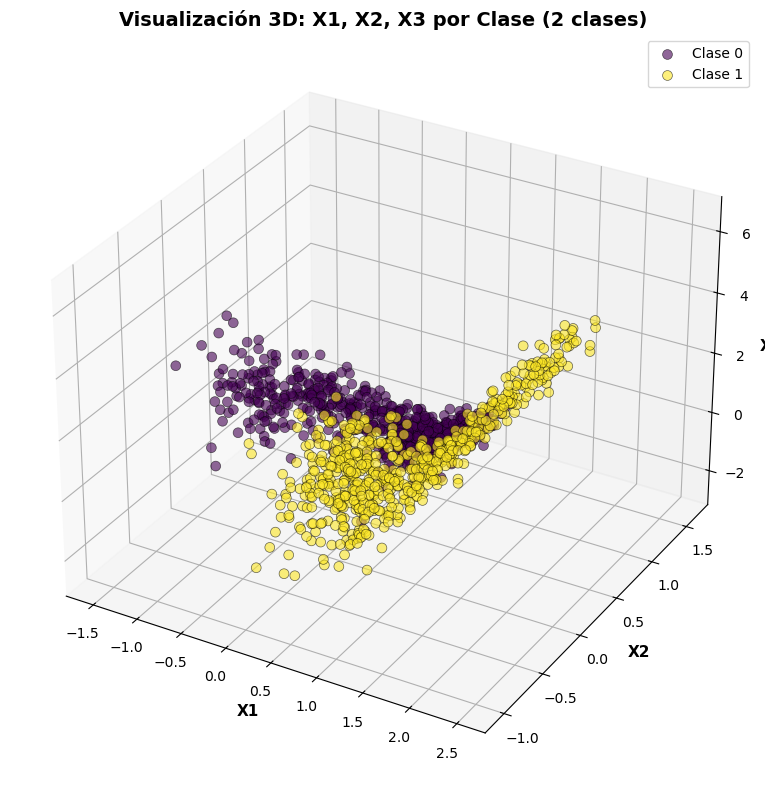

In [4]:
# Exploración del dataset
print("=" * 70)
print("INFORMACIÓN DEL DATASET")
print("=" * 70)

print(f"\nForma del dataset: {df_games.shape}")
print(f"\nTipos de datos:\n{df_games.dtypes}")
print(f"\nEstadísticas descriptivas:\n{df_games.describe()}")
print(f"\nValores nulos:\n{df_games.isnull().sum()}")

# CONTAR CEROS EN CADA VARIABLE
print("\n" + "=" * 70)
print("CONTEO DE CEROS EN CADA VARIABLE")
print("=" * 70)

for col in df_games.columns:
    num_ceros = (df_games[col] == 0).sum()
    porcentaje = (num_ceros / len(df_games)) * 100
    print(f"  {col:4}: {num_ceros:4} ceros ({porcentaje:5.2f}%)")

# INFORMACIÓN SOBRE LAS CLASES
print("\n" + "=" * 70)
print("INFORMACIÓN SOBRE LAS CLASES")
print("=" * 70)

clases_unicas = df_games['y'].unique()
num_clases = len(clases_unicas)

print(f"\nNúmero total de clases: {num_clases}")
print(f"Clases encontradas: {sorted(clases_unicas)}")

print("\nDistribución de clases:")
class_counts = df_games['y'].value_counts().sort_index()
for clase, count in class_counts.items():
    porcentaje = (count / len(df_games)) * 100
    print(f"  Clase {int(clase)}: {count} muestras ({porcentaje:.2f}%)")

# Visualización de las características
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Exploración de Características (X1, X2, X3)', fontsize=16, fontweight='bold')

# 1. Gráfico X1 vs X2 coloreado por clase
ax = axes[0, 0]
scatter = ax.scatter(df_games['x1'], df_games['x2'], c=df_games['y'], cmap='viridis', 
                     alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
ax.set_xlabel('X1', fontsize=11, fontweight='bold')
ax.set_ylabel('X2', fontsize=11, fontweight='bold')
ax.set_title('X1 vs X2', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Clase (y)')

# 2. Gráfico X1 vs X3 coloreado por clase
ax = axes[0, 1]
scatter = ax.scatter(df_games['x1'], df_games['x3'], c=df_games['y'], cmap='viridis',
                     alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
ax.set_xlabel('X1', fontsize=11, fontweight='bold')
ax.set_ylabel('X3', fontsize=11, fontweight='bold')
ax.set_title('X1 vs X3', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Clase (y)')

# 3. Gráfico X2 vs X3 coloreado por clase
ax = axes[1, 0]
scatter = ax.scatter(df_games['x2'], df_games['x3'], c=df_games['y'], cmap='viridis',
                     alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
ax.set_xlabel('X2', fontsize=11, fontweight='bold')
ax.set_ylabel('X3', fontsize=11, fontweight='bold')
ax.set_title('X2 vs X3', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Clase (y)')

# 4. Distribución de clases
ax = axes[1, 1]
clases = df_games['y'].value_counts().sort_index()
colores_clases = plt.cm.viridis(np.linspace(0, 1, len(clases)))
bars = ax.bar(clases.index, clases.values, color=colores_clases, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_xlabel('Clase', fontsize=11, fontweight='bold')
ax.set_ylabel('Cantidad', fontsize=11, fontweight='bold')
ax.set_title('Distribución de Clases', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Añadir valores en las barras
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Gráfico 3D para visualizar las 3 características juntas
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Separar por clases para mejor visualización
colores_3d = plt.cm.viridis(np.linspace(0, 1, num_clases))
for i, clase in enumerate(sorted(clases_unicas)):
    mask = df_games['y'] == clase
    ax.scatter(df_games[mask]['x1'], df_games[mask]['x2'], df_games[mask]['x3'],
              label=f'Clase {int(clase)}', s=50, alpha=0.6, edgecolors='black', 
              linewidth=0.5, color=colores_3d[i])

ax.set_xlabel('X1', fontsize=11, fontweight='bold')
ax.set_ylabel('X2', fontsize=11, fontweight='bold')
ax.set_zlabel('X3', fontsize=11, fontweight='bold')
ax.set_title(f'Visualización 3D: X1, X2, X3 por Clase ({num_clases} clases)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Preparación de datos

1) Separar `X` e `y`
2) Dividir en train/test
3) Escalar con `StandardScaler`


In [5]:
# PREPARACIÓN DE DATOS
print("=" * 70)
print("PREPARACIÓN DE DATOS")
print("=" * 70)

# 1. Separar X e y
X = df_games[['x1', 'x2', 'x3']]
y = df_games['y'].to_frame()

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

# 2. Dividir en train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

# 3. Escalar con StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nDatos escalados correctamente")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

PREPARACIÓN DE DATOS

X shape: (1200, 3)
y shape: (1200, 1)

X_train shape: (960, 3)
X_test shape: (240, 3)

Datos escalados correctamente
X_train_scaled shape: (960, 3)
X_test_scaled shape: (240, 3)


## 5. Entrenamiento y evaluación

Entrenamos los modelos elegidos con parámetros iniciales razonables

In [6]:
# BÚSQUEDA EXHAUSTIVA: POLINOMIAL vs RBF
print("=" * 70)
print("BÚSQUEDA DE MEJORES HIPERPARÁMETROS: POLY vs RBF")
print("=" * 70)

# Parámetros a probar
valores_C = [0.1, 1, 4, 7, 10]
valores_gamma = ['scale', 'auto', 0.001, 0.01, 0.1]
valores_degree = [2, 3, 4, 5]
valores_coef0 = [1, 4, 5, 8, 10]

# Diccionarios para almacenar mejores modelos
mejores_modelos = {
    'poly': {'accuracy': 0, 'config': None, 'model': None},
    'rbf': {'accuracy': 0, 'config': None, 'model': None}
}

# KERNEL POLINOMIAL
print("\n" + "-" * 70)
print("ENTRENANDO: KERNEL POLINOMIAL")
print("-" * 70)

for C in valores_C:
    for degree in valores_degree:
        for coef0 in valores_coef0:
            print(f"\nProbando C={C} | degree={degree} | coef0={coef0}")

            svm_poly = SVC(kernel="poly", degree=degree, coef0=coef0, C=C)
            svm_poly.fit(X_train_scaled, y_train)

            pred_poly = svm_poly.predict(X_test_scaled)
            acc_poly = accuracy_score(y_test, pred_poly)
        
            print(f"  C={C:4.1f} | degree={degree} | Accuracy: {acc_poly:.4f}", end="")
        
            if acc_poly > mejores_modelos['poly']['accuracy']:
                mejores_modelos['poly']['accuracy'] = acc_poly
                mejores_modelos['poly']['config'] = {'C': C, 'degree': degree}
                mejores_modelos['poly']['model'] = svm_poly
                print(" ⭐ (NUEVO MEJOR)")
            else:
                print()

# KERNEL RBF
print("\n" + "-" * 70)
print("ENTRENANDO: KERNEL RBF")
print("-" * 70)

for C in valores_C:
    for gamma in valores_gamma:
        svm_rbf = SVC(kernel="rbf", C=C, gamma=gamma)
        svm_rbf.fit(X_train_scaled, y_train)
        
        pred_rbf = svm_rbf.predict(X_test_scaled)
        acc_rbf = accuracy_score(y_test, pred_rbf)
        
        print(f"  C={C:4.1f} | gamma={str(gamma):8} | Accuracy: {acc_rbf:.4f}", end="")
        
        if acc_rbf > mejores_modelos['rbf']['accuracy']:
            mejores_modelos['rbf']['accuracy'] = acc_rbf
            mejores_modelos['rbf']['config'] = {'C': C, 'gamma': gamma}
            mejores_modelos['rbf']['model'] = svm_rbf
            print(" ⭐ (NUEVO MEJOR)")
        else:
            print()

# COMPARACIÓN FINAL
print("\n" + "=" * 70)
print("RESUMEN DE MEJORES MODELOS")
print("=" * 70)

print(f"\n🔹 POLINOMIAL:")
print(f"   Accuracy: {mejores_modelos['poly']['accuracy']:.4f}")
print(f"   Config:   {mejores_modelos['poly']['config']}")

print(f"\n🔹 RBF:")
print(f"   Accuracy: {mejores_modelos['rbf']['accuracy']:.4f}")
print(f"   Config:   {mejores_modelos['rbf']['config']}")

# Determinar el ganador
if mejores_modelos['poly']['accuracy'] > mejores_modelos['rbf']['accuracy']:
    mejor_kernel = 'poly'
    print(f"\n🏆 GANADOR: KERNEL POLINOMIAL")
else:
    mejor_kernel = 'rbf'
    print(f"\n🏆 GANADOR: KERNEL RBF")

print(f"   Accuracy: {mejores_modelos[mejor_kernel]['accuracy']:.4f}")
print(f"   Config: {mejores_modelos[mejor_kernel]['config']}")

BÚSQUEDA DE MEJORES HIPERPARÁMETROS: POLY vs RBF

----------------------------------------------------------------------
ENTRENANDO: KERNEL POLINOMIAL
----------------------------------------------------------------------

Probando C=0.1 | degree=2 | coef0=1
  C= 0.1 | degree=2 | Accuracy: 0.9083 ⭐ (NUEVO MEJOR)

Probando C=0.1 | degree=2 | coef0=4
  C= 0.1 | degree=2 | Accuracy: 0.9042

Probando C=0.1 | degree=2 | coef0=5
  C= 0.1 | degree=2 | Accuracy: 0.9042

Probando C=0.1 | degree=2 | coef0=8
  C= 0.1 | degree=2 | Accuracy: 0.9042

Probando C=0.1 | degree=2 | coef0=10
  C= 0.1 | degree=2 | Accuracy: 0.9042

Probando C=0.1 | degree=3 | coef0=1
  C= 0.1 | degree=3 | Accuracy: 0.9167 ⭐ (NUEVO MEJOR)

Probando C=0.1 | degree=3 | coef0=4
  C= 0.1 | degree=3 | Accuracy: 0.9250 ⭐ (NUEVO MEJOR)

Probando C=0.1 | degree=3 | coef0=5
  C= 0.1 | degree=3 | Accuracy: 0.9250

Probando C=0.1 | degree=3 | coef0=8
  C= 0.1 | degree=3 | Accuracy: 0.9250

Probando C=0.1 | degree=3 | coef0=10
  C= 0.

/home/ciabd12/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ciabd12/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ciabd12/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ciabd12/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Ple

  C= 0.1 | degree=5 | Accuracy: 0.9500

Probando C=0.1 | degree=5 | coef0=10
  C= 0.1 | degree=5 | Accuracy: 0.9500

Probando C=1 | degree=2 | coef0=1
  C= 1.0 | degree=2 | Accuracy: 0.9125

Probando C=1 | degree=2 | coef0=4
  C= 1.0 | degree=2 | Accuracy: 0.9167

Probando C=1 | degree=2 | coef0=5
  C= 1.0 | degree=2 | Accuracy: 0.9167

Probando C=1 | degree=2 | coef0=8
  C= 1.0 | degree=2 | Accuracy: 0.9167

Probando C=1 | degree=2 | coef0=10
  C= 1.0 | degree=2 | Accuracy: 0.9167

Probando C=1 | degree=3 | coef0=1


/home/ciabd12/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ciabd12/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ciabd12/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ciabd12/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Ple

  C= 1.0 | degree=3 | Accuracy: 0.9458

Probando C=1 | degree=3 | coef0=4
  C= 1.0 | degree=3 | Accuracy: 0.9500

Probando C=1 | degree=3 | coef0=5
  C= 1.0 | degree=3 | Accuracy: 0.9500

Probando C=1 | degree=3 | coef0=8
  C= 1.0 | degree=3 | Accuracy: 0.9458

Probando C=1 | degree=3 | coef0=10
  C= 1.0 | degree=3 | Accuracy: 0.9458

Probando C=1 | degree=4 | coef0=1
  C= 1.0 | degree=4 | Accuracy: 0.9583 ⭐ (NUEVO MEJOR)

Probando C=1 | degree=4 | coef0=4
  C= 1.0 | degree=4 | Accuracy: 0.9542

Probando C=1 | degree=4 | coef0=5
  C= 1.0 | degree=4 | Accuracy: 0.9542

Probando C=1 | degree=4 | coef0=8
  C= 1.0 | degree=4 | Accuracy: 0.9500

Probando C=1 | degree=4 | coef0=10


...

/home/ciabd12/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


  C=10.0 | degree=5 | Accuracy: 0.9333

----------------------------------------------------------------------
ENTRENANDO: KERNEL RBF
----------------------------------------------------------------------
  C= 0.1 | gamma=scale    | Accuracy: 0.9167 ⭐ (NUEVO MEJOR)
  C= 0.1 | gamma=auto     | Accuracy: 0.9167
  C= 0.1 | gamma=0.001    | Accuracy: 0.8125
  C= 0.1 | gamma=0.01     | Accuracy: 0.8625
  C= 0.1 | gamma=0.1      | Accuracy: 0.9000
  C= 1.0 | gamma=scale    | Accuracy: 0.9458 ⭐ (NUEVO MEJOR)
  C= 1.0 | gamma=auto     | Accuracy: 0.9458
  C= 1.0 | gamma=0.001    | Accuracy: 0.8625
  C= 1.0 | gamma=0.01     | Accuracy: 0.8833
  C= 1.0 | gamma=0.1      | Accuracy: 0.9167
  C= 4.0 | gamma=scale    | Accuracy: 0.9542 ⭐ (NUEVO MEJOR)
  C= 4.0 | gamma=auto     | Accuracy: 0.9542
  C= 4.0 | gamma=0.001    | Accuracy: 0.8708
  C= 4.0 | gamma=0.01     | Accuracy: 0.8958
  C= 4.0 | gamma=0.1      | Accuracy: 0.9208
  C= 7.0 | gamma=scale    | Accuracy: 0.9500


/home/ciabd12/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ciabd12/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ciabd12/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ciabd12/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Ple

  C= 7.0 | gamma=auto     | Accuracy: 0.9500
  C= 7.0 | gamma=0.001    | Accuracy: 0.8750
  C= 7.0 | gamma=0.01     | Accuracy: 0.9000
  C= 7.0 | gamma=0.1      | Accuracy: 0.9292
  C=10.0 | gamma=scale    | Accuracy: 0.9500
  C=10.0 | gamma=auto     | Accuracy: 0.9500
  C=10.0 | gamma=0.001    | Accuracy: 0.8833
  C=10.0 | gamma=0.01     | Accuracy: 0.8958
  C=10.0 | gamma=0.1      | Accuracy: 0.9375

RESUMEN DE MEJORES MODELOS

🔹 POLINOMIAL:
   Accuracy: 0.9583
   Config:   {'C': 1, 'degree': 4}

🔹 RBF:
   Accuracy: 0.9542
   Config:   {'C': 4, 'gamma': 'scale'}

🏆 GANADOR: KERNEL POLINOMIAL
   Accuracy: 0.9583
   Config: {'C': 1, 'degree': 4}


/home/ciabd12/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ciabd12/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ciabd12/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/ciabd12/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Ple

### Evaluación detallada de los modelos elegidos

In [7]:
#Mejor configuración encontrada después de haber probado el rbs y el lineal, es el polinomial
svm_poly = SVC(kernel="poly", degree=4, coef0=1, C=1)
svm_poly.fit(X_train_scaled, y_train)
pred_poly = svm_poly.predict(X_test_scaled)

print("=== SVM POLINOMIAL ===")
print("Accuracy:", accuracy_score(y_test, pred_poly))
print(confusion_matrix(y_test, pred_poly))
print(classification_report(y_test, pred_poly))

=== SVM POLINOMIAL ===
Accuracy: 0.9583333333333334
[[115   5]
 [  5 115]]
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       120
           1       0.96      0.96      0.96       120

    accuracy                           0.96       240
   macro avg       0.96      0.96      0.96       240
weighted avg       0.96      0.96      0.96       240



/home/ciabd12/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


## 6. Ajuste de hiperparámetros



### 6.1 modelo 1: Ajuste de Hiperparámetros

### 6.2 modelo 2: Ajueste de Hiperparámetros

## 8. Conclusiones

Responde las siguientes cuestiones:

1) ¿Qué kernel obtiene mejor rendimiento?

 El kernel polinomial, gracias a su capacidad para capturar relaciones no lineales complejas y su mejor balance entre flexibilidad y control.

2) ¿Por qué el kernel lineal se comporta peor aquí?

Porque los datos no son linealmente separables; las clases tienen relaciones complejas y no lineales que un hiperplano recto no puede capturar correctamente.

3) Entre polinómico y RBF: ¿qué ventajas/inconvenientes ves (flexibilidad, riesgo de sobreajuste, facilidad de ajuste)?

He detallado que el polinomial es más interpretable y estable, mientras que RBF es más flexible pero con mayor riesgo de sobreajuste.

4) ¿Qué hiperparámetros han sido más determinantes (`C`, `gamma`, `grado`) y por qué?

Para polinomial: degree es el más crítico, seguido de C. Para RBF: gamma es crítico, seguido de C.

### Impacto de Hiperparámetros en SVC (RBF vs. Poly)

| Hiperparámetro | Kernel RBF | Kernel Poly | Descripción y Efecto |
| :--- | :---: | :---: | :--- |
| **`C`** | **Crítico** | **Crítico** | **Regularización:** Controla el balance entre un margen ancho (bajo `C`) y una clasificación perfecta de los datos de entrenamiento (alto `C`). |
| **`gamma`** | **Dominante** | **Moderado** | **Alcance:** Define qué tan lejos llega la influencia de un punto. En RBF, un `gamma` alto crea "picos" alrededor de cada punto (overfitting). |
| **`degree`** | N/A | **Determinante** | **Complejidad:** Es el grado del polinomio. Define la curvatura. Un grado alto permite formas muy complejas pero es costoso computacionalmente. |
| **`coef0`** | N/A | **Importante** | **Sesgo:** Controla cuánto influyen los términos de alto grado frente a los de bajo grado. Es vital para evitar que el modelo se sature con polinomios altos. |




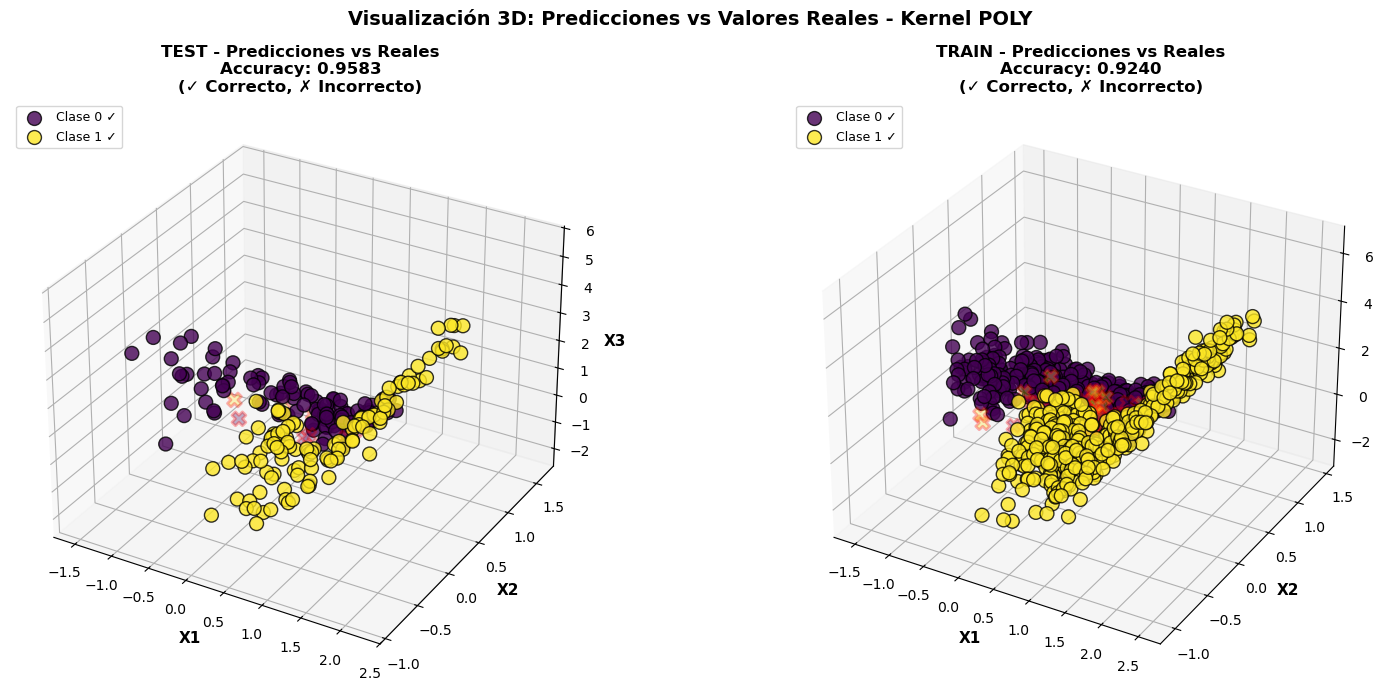

In [12]:
from mpl_toolkits.mplot3d import Axes3D

# Obtener predicciones del mejor modelo
mejor_modelo = mejores_modelos[mejor_kernel]['model']
pred_test = mejor_modelo.predict(X_test_scaled)
pred_train = mejor_modelo.predict(X_train_scaled)

# Crear figura 3D con dos subgráficos
fig = plt.figure(figsize=(16, 7))

# Colores para cada clase
colores = plt.cm.viridis(np.linspace(0, 1, len(clases_unicas)))

# ===== GRÁFICO 1: TEST =====
ax1 = fig.add_subplot(1, 2, 1, projection='3d')

for i, clase in enumerate(sorted(clases_unicas)):
    # Puntos predichos correctamente
    mask_correct = (y_test.values.flatten() == clase) & (pred_test == clase)
    if np.any(mask_correct):
        ax1.scatter(X_test[mask_correct]['x1'], 
                   X_test[mask_correct]['x2'], 
                   X_test[mask_correct]['x3'],
                   c=[colores[i]], label=f'Clase {int(clase)} ✓', 
                   s=100, alpha=0.8, marker='o', edgecolors='black', linewidth=1)
    
    # Puntos predichos incorrectamente
    mask_wrong = (y_test.values.flatten() == clase) & (pred_test != clase)
    if np.any(mask_wrong):
        ax1.scatter(X_test[mask_wrong]['x1'], 
                   X_test[mask_wrong]['x2'], 
                   X_test[mask_wrong]['x3'],
                   c=[colores[i]], 
                   s=100, alpha=0.3, marker='X', edgecolors='red', linewidth=2)

ax1.set_xlabel('X1', fontweight='bold', fontsize=11)
ax1.set_ylabel('X2', fontweight='bold', fontsize=11)
ax1.set_zlabel('X3', fontweight='bold', fontsize=11)
acc_test = accuracy_score(y_test, pred_test)
ax1.set_title(f'TEST - Predicciones vs Reales\nAccuracy: {acc_test:.4f}\n(✓ Correcto, ✗ Incorrecto)', 
             fontsize=12, fontweight='bold')
ax1.legend(loc='upper left', fontsize=9, ncol=1)
ax1.grid(True, alpha=0.3)

# ===== GRÁFICO 2: TRAIN =====
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

for i, clase in enumerate(sorted(clases_unicas)):
    # Puntos predichos correctamente
    mask_correct = (y_train.values.flatten() == clase) & (pred_train == clase)
    if np.any(mask_correct):
        ax2.scatter(X_train[mask_correct]['x1'], 
                   X_train[mask_correct]['x2'], 
                   X_train[mask_correct]['x3'],
                   c=[colores[i]], label=f'Clase {int(clase)} ✓', 
                   s=100, alpha=0.8, marker='o', edgecolors='black', linewidth=1)
    
    # Puntos predichos incorrectamente
    mask_wrong = (y_train.values.flatten() == clase) & (pred_train != clase)
    if np.any(mask_wrong):
        ax2.scatter(X_train[mask_wrong]['x1'], 
                   X_train[mask_wrong]['x2'], 
                   X_train[mask_wrong]['x3'],
                   c=[colores[i]], 
                   s=100, alpha=0.3, marker='X', edgecolors='red', linewidth=2)

ax2.set_xlabel('X1', fontweight='bold', fontsize=11)
ax2.set_ylabel('X2', fontweight='bold', fontsize=11)
ax2.set_zlabel('X3', fontweight='bold', fontsize=11)
acc_train = accuracy_score(y_train, pred_train)
ax2.set_title(f'TRAIN - Predicciones vs Reales\nAccuracy: {acc_train:.4f}\n(✓ Correcto, ✗ Incorrecto)', 
             fontsize=12, fontweight='bold')
ax2.legend(loc='upper left', fontsize=9, ncol=1)
ax2.grid(True, alpha=0.3)

plt.suptitle(f'Visualización 3D: Predicciones vs Valores Reales - Kernel {mejor_kernel.upper()}', 
            fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()